# Load Project Data

In [ ]:
import numpy as np
import pandas as pd
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import math
# from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ==============================
# Load Project Data
# ==============================

gid_path = "1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY"

gdown.download(
    id = gid_path,
    output="get_it_done_requests_closed_2025_datasd.csv",
    quiet=False
)

gid_requests = pd.read_csv("get_it_done_requests_closed_2025_datasd.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY
From (redirected): https://drive.google.com/uc?id=1qvELtIxFwFRJ3lLPI0PvLrhH_6VPwxXY&confirm=t&uuid=8c7741ba-313d-4d9e-ae32-ba0ba29b92b0
To: /content/get_it_done_requests_closed_2025_datasd.csv
100%|██████████| 128M/128M [00:03<00:00, 39.3MB/s]


# High-Level Overview and MetaData Report

In [ ]:
gid_requests.shape

(378669, 23)

In [ ]:
gid_requests.head()

,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
0,5152704,NaN,NaN,2025-03-19 16:20:00.000,0,TSW,Pothole,NaN,2025-03-19,Referred,...,NaN,6.0,15.0,MIRA MESA,NaN,Mobile,This report has been referred to appropriate d...,SS-001649-PV1,SS-001649-PV1,Broken cover. || LOCATION: 7489 Acama st 92126...
1,5152705,NaN,NaN,2025-03-19 16:22:00.000,1,ESD Complaint/Report,Missed Collection,Missed Collection,2025-03-20,Closed,...,92109.0,2.0,18.0,MISSION BEACH,NaN,Web,NaN,SS-035651-PV1,SA-002923-PV1,Third attempt has not been picked up
2,5152711,NaN,NaN,2025-03-19 16:25:00.000,27,Parking,Parking Violation,72 Hour Violation,2025-04-15,Closed,...,92117.0,2.0,6.0,CLAIREMONT MESA,NaN,Web,NaN,SS-013181,SS-013181,Van has been parked for over a month. Windows ...
3,5152712,NaN,NaN,2025-03-19 16:25:00.000,14,Neighborhood Policing,Encampment,NaN,2025-04-02,Closed,...,92101.0,2.0,14.0,MIDWAY-PACIFIC HIGHWAY,NaN,Web,NaN,SS-030076-PV1,SS-030076-PV1,A homeless encampment fire was reported at W. ...
4,5152714,NaN,NaN,2025-03-19 16:29:00.000,3,Parking,Parking Violation,72 Hour Violation,2025-03-22,Closed,...,92110.0,2.0,6.0,CLAIREMONT MESA,NaN,Web,NaN,SS-018336,SS-018336,Van has been parked on the curb since March 11...


In [ ]:
gid_requests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378669 entries, 0 to 378668
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   service_request_id         378669 non-null  int64  
 1   service_request_parent_id  41999 non-null   float64
 2   sap_notification_number    46831 non-null   float64
 3   date_requested             378669 non-null  object 
 4   case_age_days              378669 non-null  int64  
 5   case_record_type           378669 non-null  object 
 6   service_name               378489 non-null  object 
 7   service_name_detail        240280 non-null  object 
 8   date_closed                378669 non-null  object 
 9   status                     378669 non-null  object 
 10  lat                        378270 non-null  float64
 11  lng                        378270 non-null  float64
 12  street_address             377569 non-null  object 
 13  zipcode                    37

In [ ]:
gid_requests["zipcode"] = (
    gid_requests["zipcode"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

gid_requests["comm_plan_code"] = (
    gid_requests["comm_plan_code"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

gid_requests["council_district"] = (
    gid_requests["council_district"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

Observed that there are no integer-coded categorical features that need to be switched to categorical types

In [ ]:
gid_requests.nunique()

,0
service_request_id,378669
service_request_parent_id,25696
sap_notification_number,46830
date_requested,234665
case_age_days,2442
case_record_type,12
service_name,42
service_name_detail,262
date_closed,365
status,2


In [ ]:
def create_metadata(df) :
    # Initialize DataFrame object with index (row names) as feature names
    meta = pd.DataFrame(index=df.columns)
    # Extract variable types
    meta['dtype'] = df.dtypes
    # Extract number of unique values
    meta['n_unique'] = df.nunique()
    # Number of missing values
    meta['missing_sum'] = df.isnull().sum()
    # Whether feature is numeric
    meta['is_numeric'] = meta['dtype'].apply(
        lambda x: pd.api.types.is_numeric_dtype(x)
    )
    # Whether feature is categorical
    meta['is_categorical'] = meta['dtype'].apply(
        lambda x: isinstance(x, pd.CategoricalDtype) or x == object
    )
    # Sample of values (that are not missing) from dataset
    #meta['sample_values'] = df.apply(lambda col: col.dropna().unique()[:5])
    # Return metadata DataFrame
    return meta

# Run the method on DataFrame and generate report
meta_df = create_metadata(gid_requests)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,378669,0,True,False
service_request_parent_id,float64,25696,336670,True,False
sap_notification_number,float64,46830,331838,True,False
date_requested,object,234665,0,False,True
case_age_days,int64,2442,0,True,False
case_record_type,object,12,0,False,True
service_name,object,42,180,False,True
service_name_detail,object,262,138389,False,True
date_closed,object,365,0,False,True
status,object,2,0,False,True


# Exploratory Data Analysis

In [ ]:
# Count, Mean, Standard Deviation, Min,
# Q1, Median, Q3, Max
summary = gid_requests.describe(include = "int64").T

# Skewness describes whether data is assymetric (not centered)
summary["skew"] = gid_requests.select_dtypes(
    include = "int64"
).skew()

# Kurtosis describes whether data is heavy-tailed (outliers)
summary["kurtosis"] = gid_requests.select_dtypes(
    include = "int64"
).kurt()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
service_request_id,378669.0,5.221576e+06,297641.883433,82529.0,5138245.0,5253320.0,5373489.0,5606526.0,-6.794564,79.371714
case_age_days,378669.0,4.609077e+01,194.383769,-124.0,0.0,2.0,14.0,3478.0,8.064617,81.012409


Observe that case_age_days is probably the only numeric column here with any real meaning

In [ ]:
def plot_boxplot_grid(
    df, cols_per_row=5, figsize_per_plot=(4, 3),
    title='Boxplots of Numeric Features'
):
    # Extract numeric features & calculate plots per row in grid
    numeric_cols = df.select_dtypes(include='int64').columns
    n_cols = len(numeric_cols)

    # Determine grid size
    n_rows = math.ceil(n_cols / cols_per_row)

    # Setup subplots
    fig, axes = plt.subplots(
        n_rows, cols_per_row,
        figsize=(cols_per_row * figsize_per_plot[0],
                 n_rows * figsize_per_plot[1])
    )
    axes = axes.flatten()

    # Create each boxplot
    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_xlabel("")

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

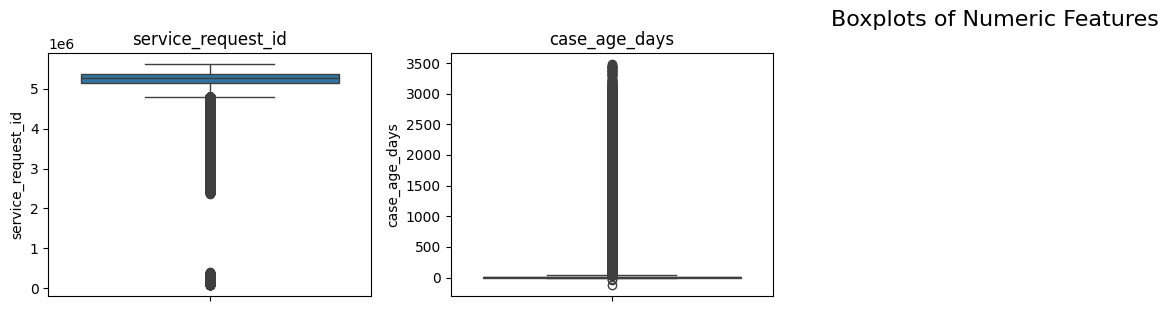

In [ ]:
plot_boxplot_grid(df = gid_requests)

Some outliers are squishing the box plot for case age days (don't really care about service request ID)

In [ ]:
gid_requests["case_age_days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

,case_age_days
0.50,2.00
0.75,14.00
0.90,67.00
0.95,182.00
0.99,958.32
1.00,3478.00


Boxplot for case age days with outliers removed

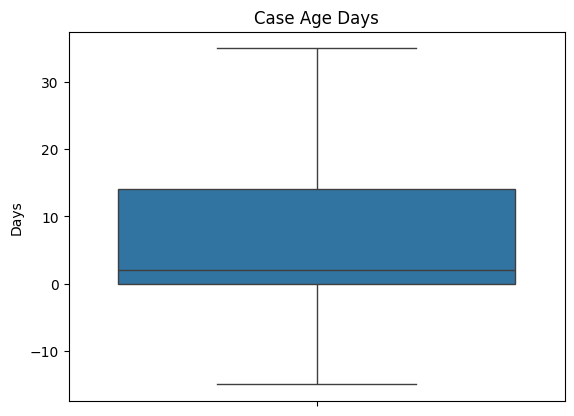

In [ ]:
sns.boxplot(
    y=gid_requests["case_age_days"],
    showfliers=False
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

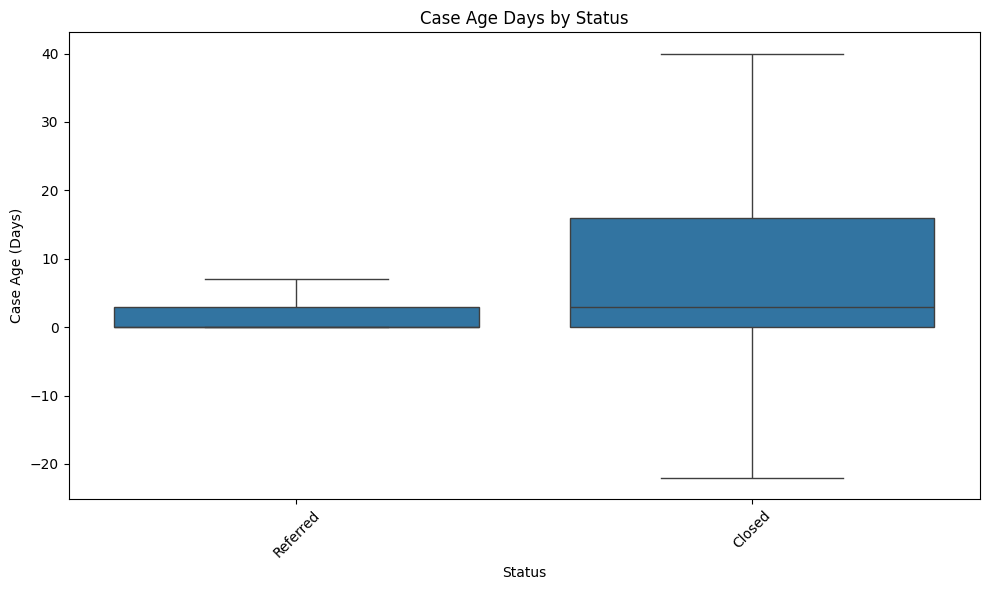

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=gid_requests,
    x="status",
    y="case_age_days",
    showfliers=False
)

plt.title("Case Age Days by Status")
plt.xlabel("Status")
plt.ylabel("Case Age (Days)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
(gid_requests["status"] == "Referred").sum()

np.int64(27958)

Going to remove cases referred

Inspecting outliers in code below (15 standard deviations from mean for case age days) - going to leave them in for now

In [ ]:
# Filter to Closed cases
closed_cases = gid_requests[gid_requests["status"] == "Closed"].copy()

# Calculate mean and standard deviation
mean_age = closed_cases["case_age_days"].mean()
std_age = closed_cases["case_age_days"].std()

# Define +/- 3 standard deviations
lower_bound = mean_age - (15 * std_age)
upper_bound = mean_age + (15 * std_age)

# Find cases outside those bounds
closed_outliers = closed_cases[
    (closed_cases["case_age_days"] < lower_bound) |
    (closed_cases["case_age_days"] > upper_bound)
]


print(closed_outliers.shape)
closed_outliers.head()

(57, 23)


,service_request_id,service_request_parent_id,sap_notification_number,date_requested,case_age_days,case_record_type,service_name,service_name_detail,date_closed,status,...,zipcode,council_district,comm_plan_code,comm_plan_name,park_name,case_origin,referred,iamfloc,floc,public_description
75683,86874,NaN,4.030000e+10,2016-06-08 18:45:00.000,3478,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-16,Closed,...,nan,9,58,MID-CITY:KENSINGTON-TALMADGE,NaN,Mobile,NaN,SS-015118-PV1,SS-015118,Curb and sidewalk came in damaged for over thr...
75684,91703,NaN,4.030000e+10,2016-07-05 21:26:00.000,3465,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-30,Closed,...,nan,9,59,MID-CITY:NORMAL HEIGHTS,NaN,Mobile,NaN,SS-000937-PV1,SS-000937,It was broken when a city crew replaced the fi...
75685,93180,NaN,4.030000e+10,2016-07-13 15:56:00.000,3313,TSW,Pavement Maintenance,DAMAGED CURB,2025-08-08,Closed,...,nan,3,42,UPTOWN,NaN,Mobile,NaN,SS-029821-PV1,SS-029821,"Curb needs replacement, trip hazard, north cur..."
75686,95710,NaN,4.030000e+10,2016-07-25 20:30:00.000,3431,TSW,Pavement Maintenance,DAMAGED CURB,2025-12-16,Closed,...,nan,9,58,MID-CITY:KENSINGTON-TALMADGE,NaN,Web,NaN,SS-017647-PV1,SS-017647,The curb in front of our home is deteriorating...
75907,94155,NaN,4.030001e+10,2016-07-18 16:02:00.000,3411,TSW,Stormwater,DRAIN OUTFALL,2025-11-19,Closed,...,nan,3,42,UPTOWN,NaN,Web,NaN,OT00225,SS-012872,We have no drain from North Guy Street (upper)...


Removal of referred requests

In [ ]:
closed_requests = gid_requests[
    gid_requests["status"] == "Closed"
].copy()

closed_requests["council_district"] = closed_requests["council_district"].astype("category")

In [ ]:
# Count, Mean, Standard Deviation, Min,
# Q1, Median, Q3, Max
summary = closed_requests.describe(include = "int64").T

# Skewness describes whether data is assymetric (not centered)
summary["skew"] = closed_requests.select_dtypes(
    include = "int64"
).skew()

# Kurtosis describes whether data is heavy-tailed (outliers)
summary["kurtosis"] = closed_requests.select_dtypes(
    include = "int64"
).kurt()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
service_request_id,350711.0,5.218711e+06,306173.160809,82529.0,5137513.5,5253421.0,5373329.5,5606526.0,-6.685886,75.751919
case_age_days,350711.0,4.911907e+01,201.127902,-124.0,0.0,3.0,16.0,3478.0,7.793137,75.474397


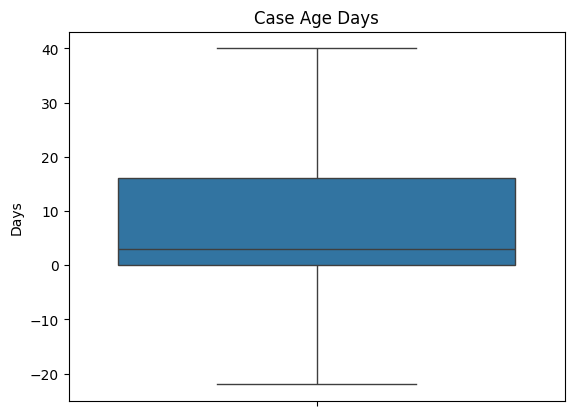

In [ ]:
sns.boxplot(
    y=closed_requests["case_age_days"],
    showfliers=False
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

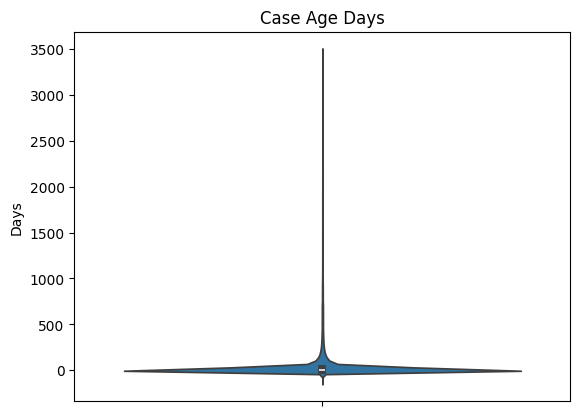

In [ ]:
sns.violinplot(
    y=closed_requests["case_age_days"]
)

plt.title("Case Age Days")
plt.ylabel("Days")
plt.show()

Lots of skew, going to keep outliers for now but might consider removing them later on

Box plots by categorical features (case record type and council district)

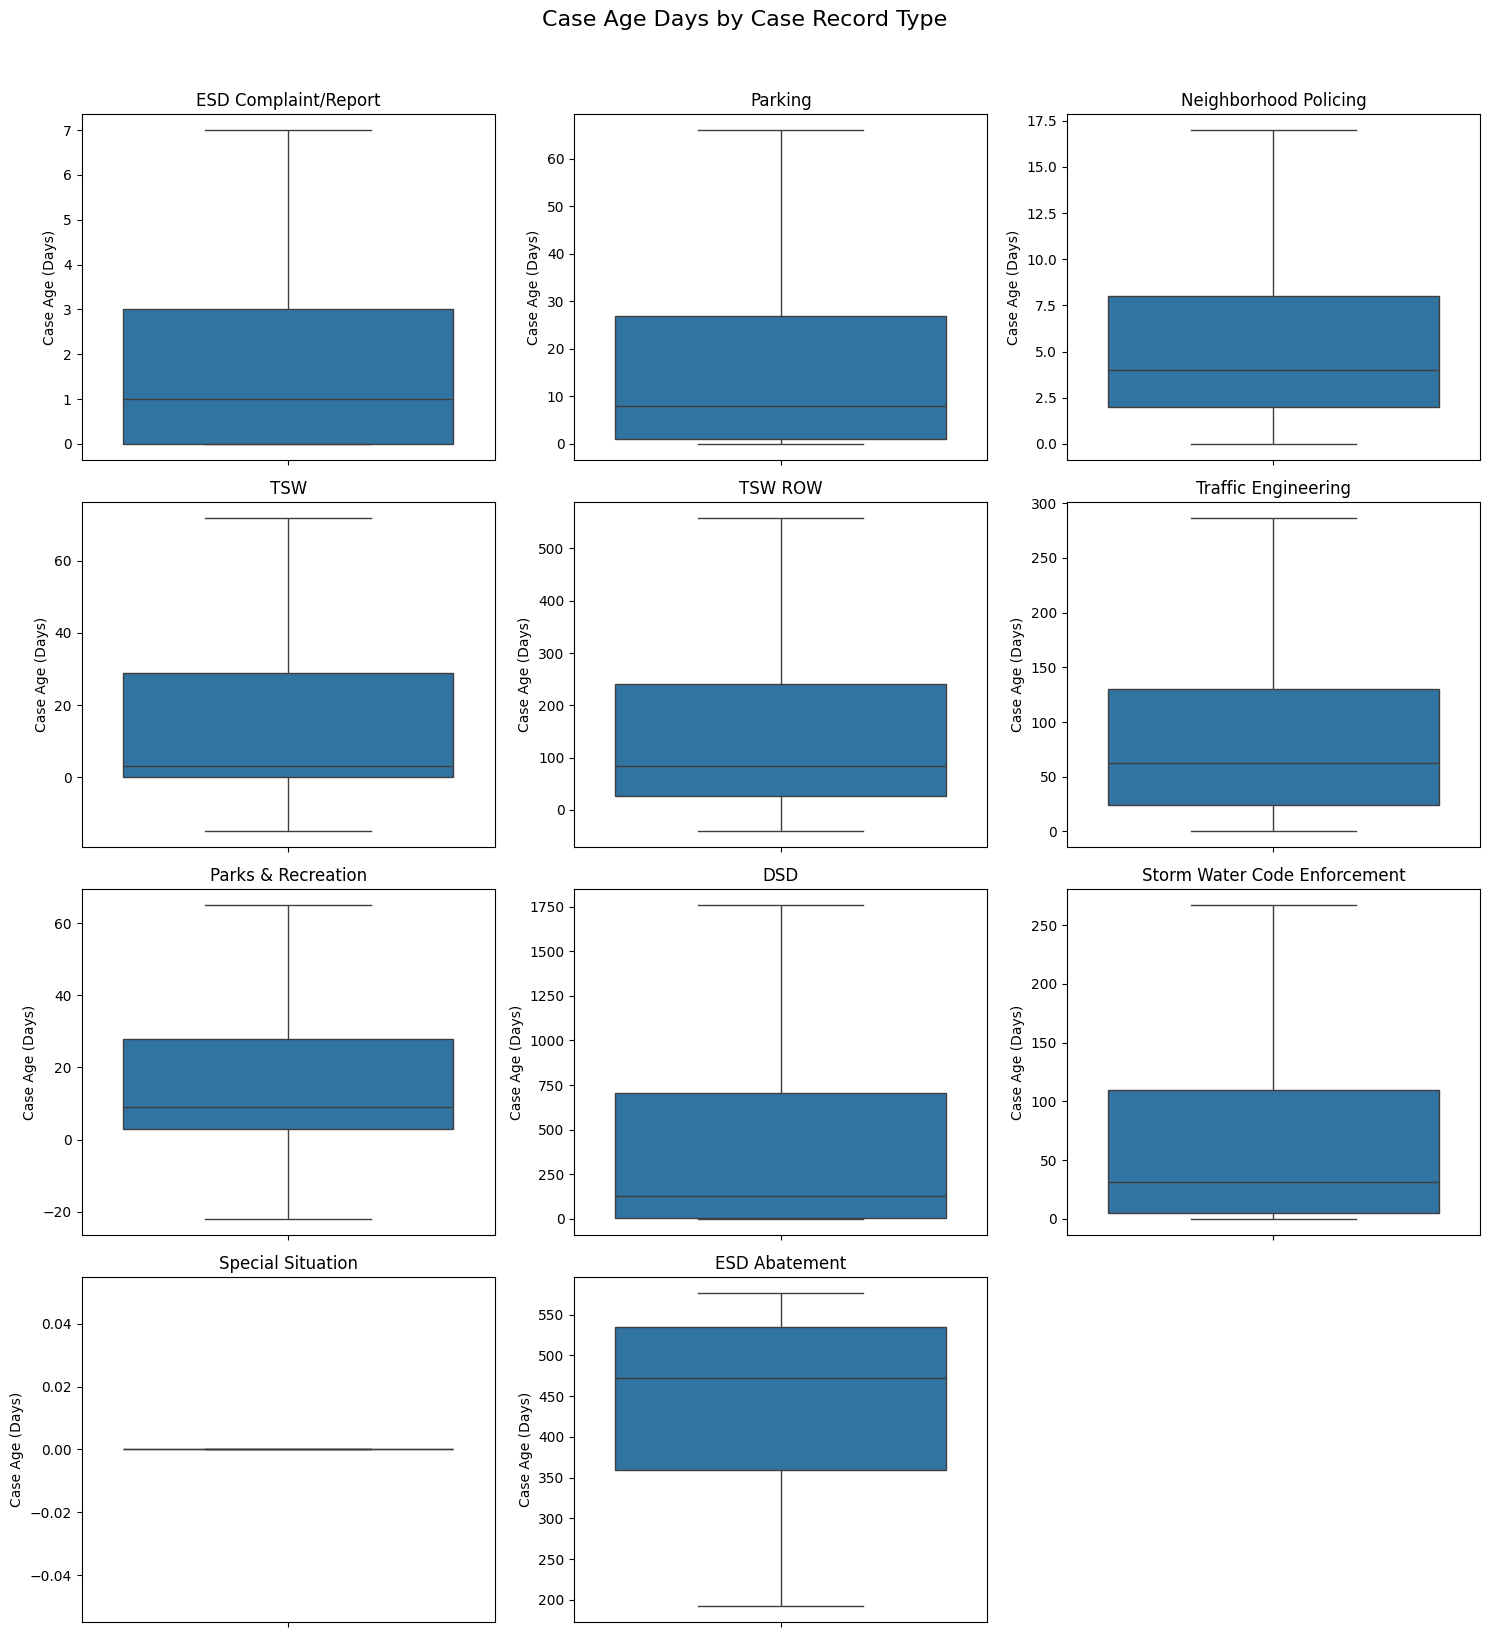

In [ ]:
# Get all unique case record types
record_types = closed_requests["case_record_type"].dropna().unique()

# Number of plots per row
cols_per_row = 3

# Calculate number of rows needed
n_rows = math.ceil(len(record_types) / cols_per_row)

# Create grid
fig, axes = plt.subplots(
    n_rows,
    cols_per_row,
    figsize=(15, 4 * n_rows)
)

# Flatten axes so they're easier to loop through
axes = axes.flatten()

# Create one boxplot for each case record type
for i, record_type in enumerate(record_types):

    subset = closed_requests[
        closed_requests["case_record_type"] == record_type
    ]

    sns.boxplot(
        y=subset["case_age_days"],
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(record_type)
    axes[i].set_ylabel("Case Age (Days)")
    axes[i].set_xlabel("")

# Remove unused plots
for j in range(len(record_types), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Case Age Days by Case Record Type",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

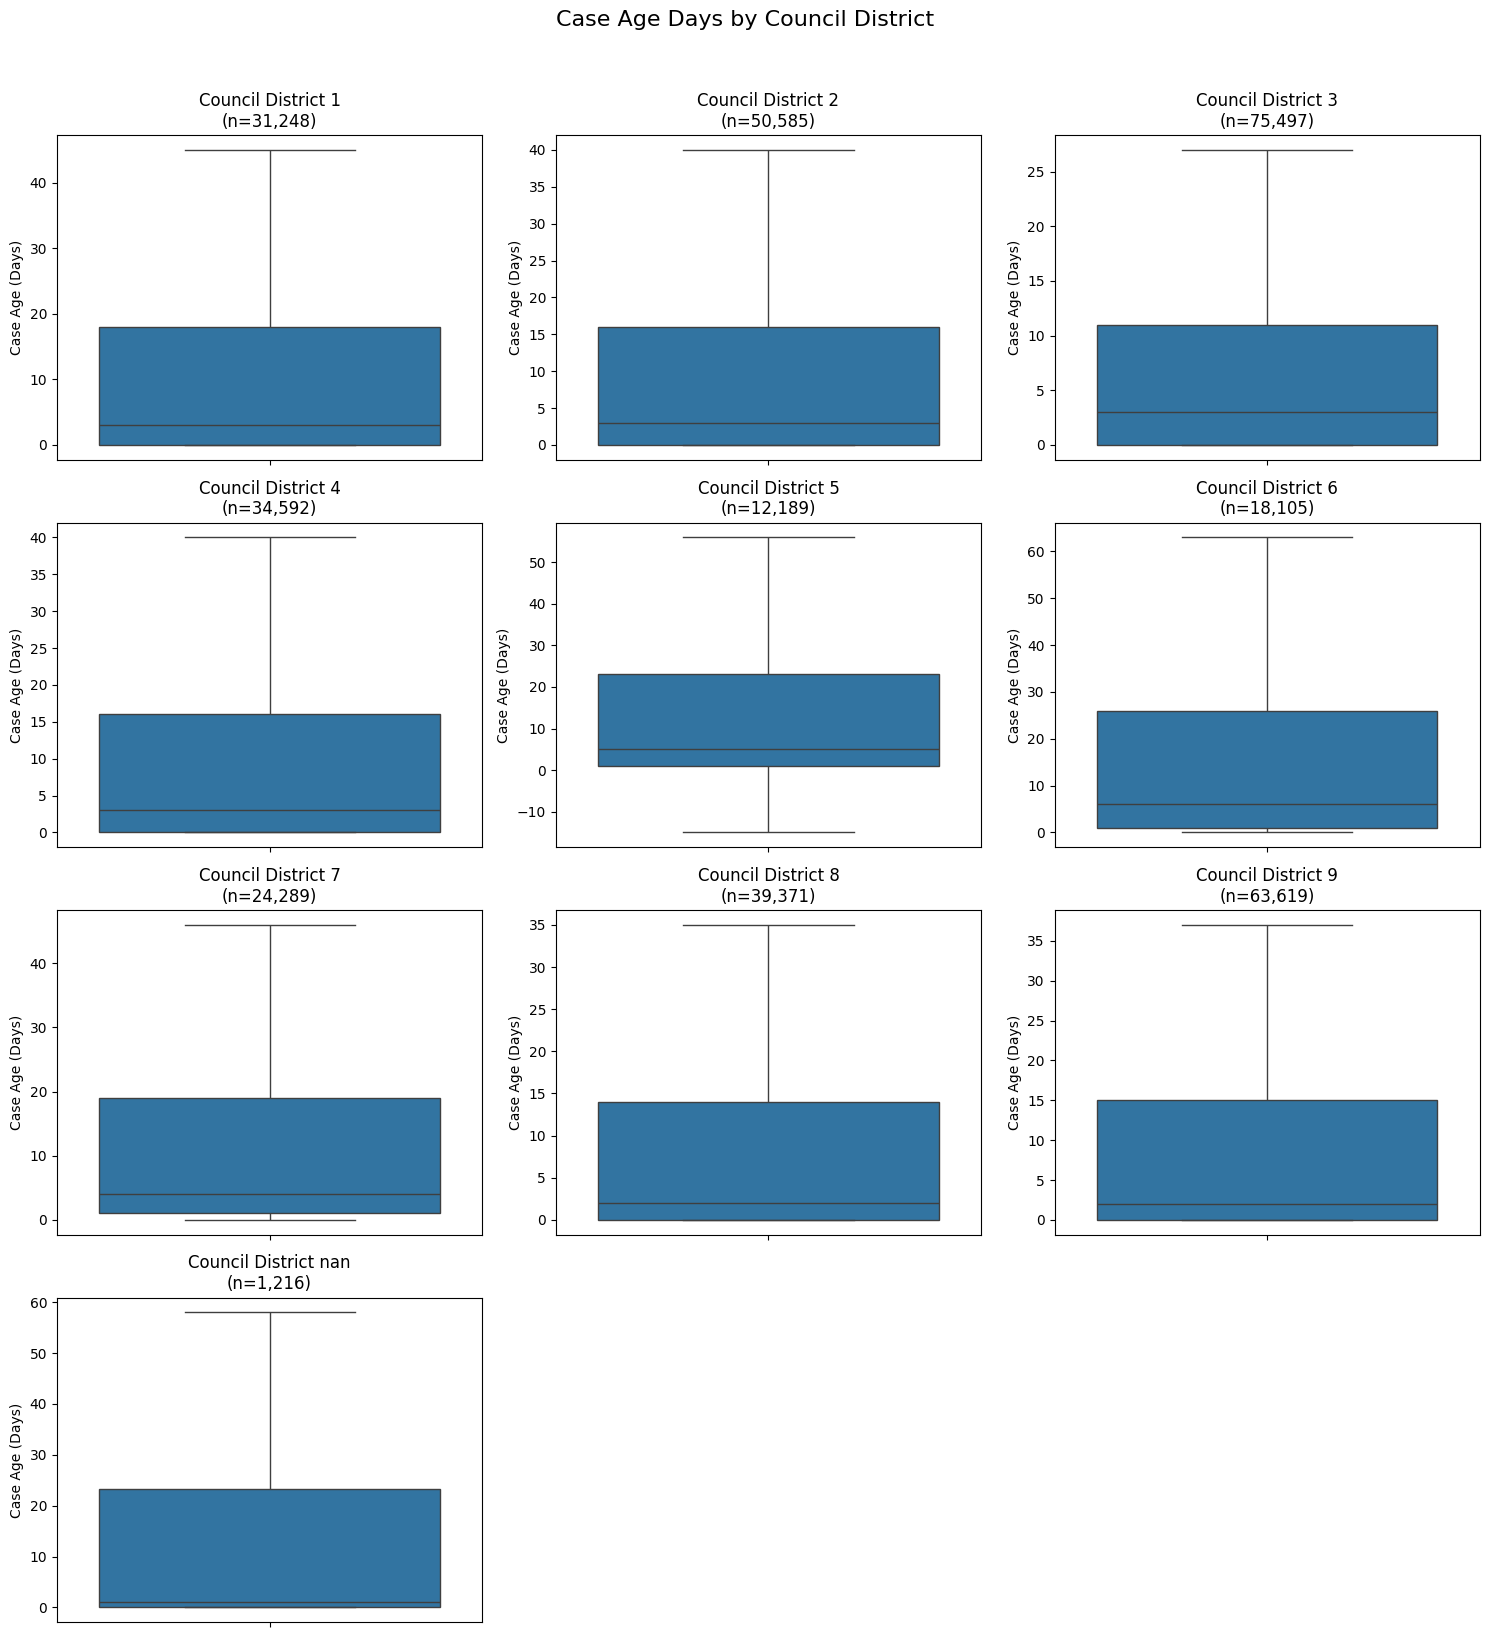

In [ ]:
# Get all unique council districts
districts = sorted(
    closed_requests["council_district"].dropna().unique()
)

# Number of plots per row
cols_per_row = 3

# Calculate number of rows
n_rows = math.ceil(len(districts) / cols_per_row)

# Create grid
fig, axes = plt.subplots(
    n_rows,
    cols_per_row,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

# Create one boxplot per council district
for i, district in enumerate(districts):

    subset = closed_requests[
        closed_requests["council_district"] == district
    ]

    sns.boxplot(
        y=subset["case_age_days"],
        ax=axes[i],
        showfliers=False
    )

    axes[i].set_title(
        f"Council District {district}\n(n={len(subset):,})"
    )
    axes[i].set_ylabel("Case Age (Days)")
    axes[i].set_xlabel("")

# Remove unused plots
for j in range(len(districts), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Case Age Days by Council District",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

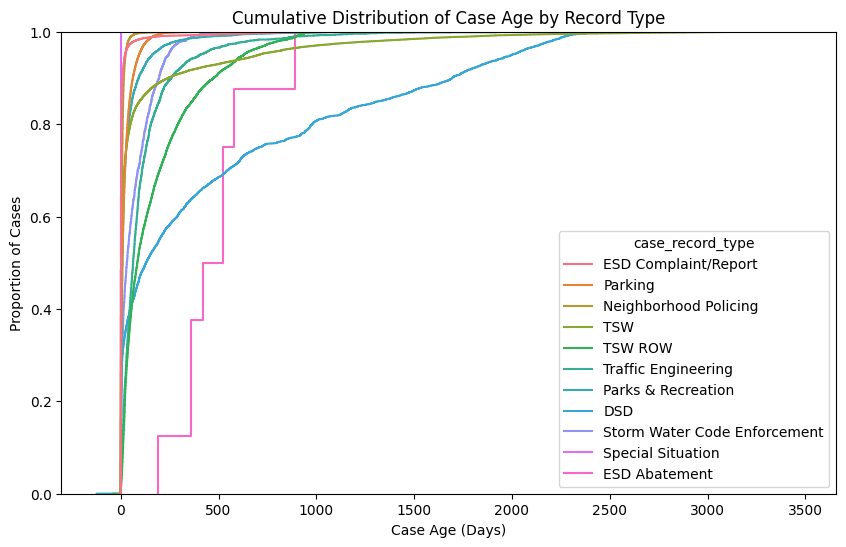

In [ ]:
plt.figure(figsize=(10, 6))

sns.ecdfplot(
    data=closed_requests,
    x="case_age_days",
    hue="case_record_type"
)

plt.xlabel("Case Age (Days)")
plt.ylabel("Proportion of Cases")
plt.title("Cumulative Distribution of Case Age by Record Type")
plt.show()

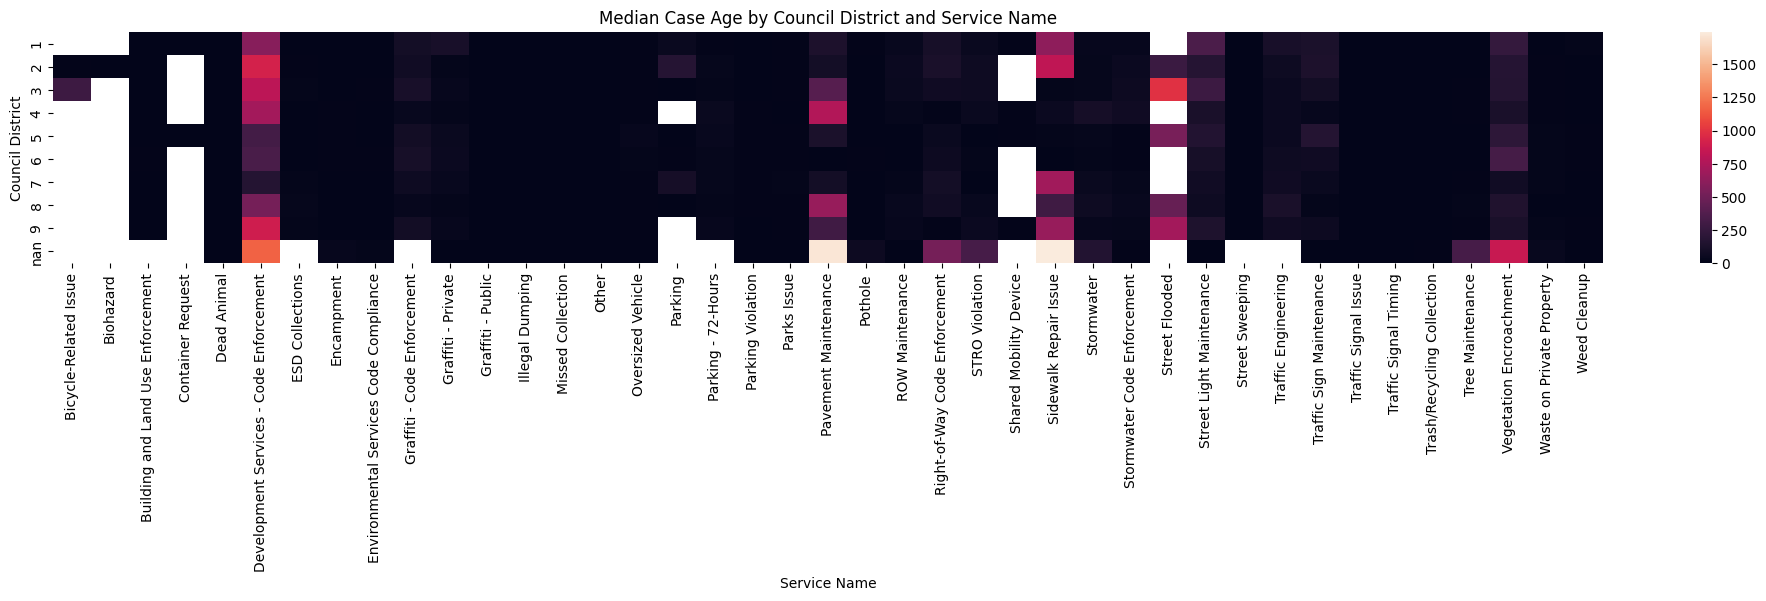

In [ ]:
heatmap_data = closed_requests.pivot_table(
    values="case_age_days",
    index="council_district",
    columns="service_name",
    aggfunc="median"
)

plt.figure(figsize=(25, 3))

sns.heatmap(
    heatmap_data,
    #annot=True,
    fmt=".1f"
)

plt.title("Median Case Age by Council District and Service Name")
plt.xlabel("Service Name")
plt.ylabel("Council District")

plt.show()

# ML Prep

select columns needed for ML

In [ ]:
ml_df = closed_requests[["service_request_id", "case_age_days", "date_requested", "date_closed", "case_record_type", "service_name", "zipcode", "council_district", "comm_plan_code", "comm_plan_name", "case_origin", "public_description"]]

In [ ]:
ml_df

,service_request_id,case_age_days,date_requested,date_closed,case_record_type,service_name,zipcode,council_district,comm_plan_code,comm_plan_name,case_origin,public_description
1,5152705,1,2025-03-19 16:22:00.000,2025-03-20,ESD Complaint/Report,Missed Collection,92109,2,18,MISSION BEACH,Web,Third attempt has not been picked up
2,5152711,27,2025-03-19 16:25:00.000,2025-04-15,Parking,Parking Violation,92117,2,6,CLAIREMONT MESA,Web,Van has been parked for over a month. Windows ...
3,5152712,14,2025-03-19 16:25:00.000,2025-04-02,Neighborhood Policing,Encampment,92101,2,14,MIDWAY-PACIFIC HIGHWAY,Web,A homeless encampment fire was reported at W. ...
4,5152714,3,2025-03-19 16:29:00.000,2025-03-22,Parking,Parking Violation,92110,2,6,CLAIREMONT MESA,Web,Van has been parked on the curb since March 11...
5,5152728,5,2025-03-19 16:37:00.000,2025-03-24,ESD Complaint/Report,Missed Collection,92113,8,37,SOUTHEASTERN SAN DIEGO,Web,Very busy street so I understand if one was mi...
...,...,...,...,...,...,...,...,...,...,...,...,...
378664,4662530,598,2024-03-11 08:48:00.000,2025-10-30,TSW ROW,Right-of-Way Code Enforcement,92128,5,31,Rancho Bernardo,Mobile,Sidewalk eneven
378665,4947796,418,2024-09-28 13:25:00.000,2025-11-20,TSW,Traffic Sign Maintenance,92130,1,21,CARMEL VALLEY,Mobile,On the rightside of eastbound Del Mar Heights ...
378666,5060477,3,2025-01-05 11:22:00.000,2025-01-08,TSW,Pothole,92122,6,99,UNIVERSITY,Web,The entrance to the dog park has a raised edge...
378667,5182329,6,2025-04-12 18:34:00.000,2025-04-18,TSW,Tree Maintenance,92117,2,6,CLAIREMONT MESA,Mobile,Tree blocking sidewalk


In [ ]:
meta_df = create_metadata(ml_df)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,350711,0,True,False
case_age_days,int64,2441,0,True,False
date_requested,object,223394,0,False,True
date_closed,object,365,0,False,True
case_record_type,object,11,0,False,True
service_name,object,41,17,False,True
zipcode,object,67,0,False,True
council_district,category,10,0,False,True
comm_plan_code,object,58,0,False,True
comm_plan_name,object,59,1252,False,True


### Dealing with missing values

In [ ]:
# drop observations with missing service name
# drop observations with missing zip code

ml_df = ml_df.dropna(
    subset=["service_name", "zipcode", "council_district", "comm_plan_code"]
)

ml_df = ml_df.reset_index(drop=True)

#most_common_origin = ml_df["case_origin"].mode()[0]
#ml_df["case_origin"] = ml_df["case_origin"].fillna(most_common_origin)

In [ ]:
meta_df = create_metadata(ml_df)

# Export to CSV file
meta_df.to_csv("metadata_report.csv")

meta_df.head(25)

,dtype,n_unique,missing_sum,is_numeric,is_categorical
service_request_id,int64,350694,0,True,False
case_age_days,int64,2441,0,True,False
date_requested,object,223389,0,False,True
date_closed,object,365,0,False,True
case_record_type,object,11,0,False,True
service_name,object,41,0,False,True
zipcode,object,66,0,False,True
council_district,category,10,0,False,True
comm_plan_code,object,58,0,False,True
comm_plan_name,object,59,1251,False,True


In [ ]:
ml_df.shape

(350694, 12)

column for day of week based on date requested, column for season based on date requested, extract text urgent from detail/public description

### Feature Engineering

In [ ]:
ml_df["date_requested"] = pd.to_datetime(
    ml_df["date_requested"]
)

ml_df["request_year"] = ml_df["date_requested"].dt.year
ml_df["request_month"] = ml_df["date_requested"].dt.month
ml_df["request_day_of_week"] = ml_df["date_requested"].dt.dayofweek
ml_df["request_quarter"] = ml_df["date_requested"].dt.quarter

In [ ]:
ml_df["date_requested"] = pd.to_datetime(ml_df["date_requested"])
ml_df["date_closed"] = pd.to_datetime(ml_df["date_closed"])

# Calculate number of days to close
days_to_close = (
    ml_df["date_closed"] - ml_df["date_requested"]
).dt.days

# Create binary target
ml_df["closed_within_30_days"] = (days_to_close <= 30).astype(int)

In [ ]:
urgent_cases = ml_df[
    ml_df["public_description"]
    .fillna("")
    .str.contains("urgent", case=False, na=False)
]

urgent_cases[
    ["service_request_id", "public_description", "case_age_days"]
]

,service_request_id,public_description,case_age_days
1592,5236532,The metal fence at the cormorant nesting site ...,204
2624,5237100,Immediate action is needed regarding severe no...,0
3409,5234436,Here?s a direct and urgent letter you can send...,9
3792,5238874,**URGENT** BROKEN STOP SIGN,2
4671,5238724,I?m following up again regarding the homeless ...,1
...,...,...,...
342408,5485188,This is a second dumpster on the property on O...,6
345572,5416565,URGENT: Silver Prius has been parked here sin...,14
346534,5490955,Two tall palm trees on city sidewalk landscape...,1
349085,5495637,Tree on 8056 san felipe st. Forgot to mention ...,1


In [ ]:
urgency_terms = [
    "urgent",
    "urgently",
    "emergency",
    "immediately",
    "immediate",
    "asap",
    "danger",
    "dangerous",
    "hazard",
    "hazardous",
    "unsafe",
    "critical"
]

pattern = "|".join(urgency_terms)

urgent_cases = ml_df[
    ml_df["public_description"]
    .fillna("")
    .str.contains(pattern, case=False, na=False)
]

In [ ]:
urgent_cases[
    ["service_request_id", "public_description", "case_age_days"]
].head(5)

,service_request_id,public_description,case_age_days
1,5152711,Van has been parked for over a month. Windows ...,27
18,5152934,Around Kettner and Grape - this area needs imm...,48
53,5153300,"LARGE POTHOLE. DANGEROUS AND HAZARDOUS, PER OF...",0
111,5153877,The new bike lane for Clairemont Dr. is causin...,1
122,5153971,Recently the sidewalk in front of the Windsor ...,26


In [ ]:
for term in urgency_terms:
    count = (
        ml_df["public_description"]
        .fillna("")
        .str.contains(term, case=False, na=False)
        .sum()
    )

    print(f"{term}: {count}")

urgent: 276
urgently: 78
emergency: 761
immediately: 760
immediate: 1516
asap: 1195
danger: 4576
dangerous: 3785
hazard: 5899
hazardous: 661
unsafe: 1528
critical: 68


In [ ]:
ml_df["urgent_language"] = (
    ml_df["public_description"]
    .fillna("")
    .str.contains(pattern, case=False, na=False)
    .astype(int)
)

In [ ]:
ml_df.groupby("urgent_language")["case_age_days"].describe()

,count,mean,std,min,25%,50%,75%,max
urgent_language,,,,,,,,
0,336189.0,45.141941,186.507959,-124.0,0.0,3.0,15.0,3478.0
1,14505.0,141.354498,403.714793,0.0,1.0,8.0,51.0,3367.0


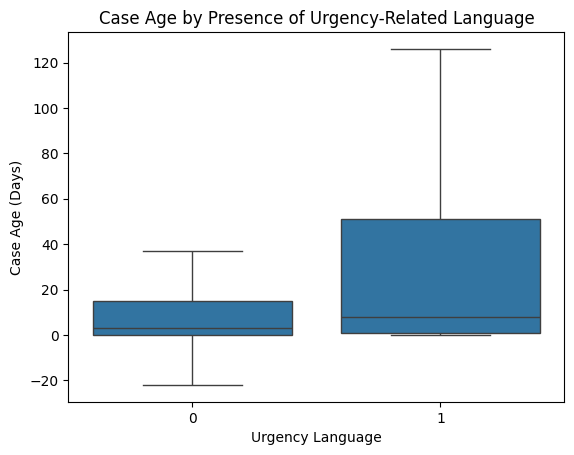

In [ ]:
sns.boxplot(
    data=ml_df,
    x="urgent_language",
    y="case_age_days",
    showfliers=False
)

plt.xlabel("Urgency Language")
plt.ylabel("Case Age (Days)")
plt.title("Case Age by Presence of Urgency-Related Language")
plt.show()

In [ ]:
ml_df = ml_df.drop(columns = ["public_description", "date_requested", "date_closed"])

In [ ]:
ml_df

,service_request_id,case_age_days,case_record_type,service_name,zipcode,council_district,comm_plan_code,comm_plan_name,case_origin,request_year,request_month,request_day_of_week,request_quarter,closed_within_30_days,urgent_language
0,5152705,1,ESD Complaint/Report,Missed Collection,92109,2,18,MISSION BEACH,Web,2025,3,2,1,1,0
1,5152711,27,Parking,Parking Violation,92117,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,1
2,5152712,14,Neighborhood Policing,Encampment,92101,2,14,MIDWAY-PACIFIC HIGHWAY,Web,2025,3,2,1,1,0
3,5152714,3,Parking,Parking Violation,92110,2,6,CLAIREMONT MESA,Web,2025,3,2,1,1,0
4,5152728,5,ESD Complaint/Report,Missed Collection,92113,8,37,SOUTHEASTERN SAN DIEGO,Web,2025,3,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350689,4662530,598,TSW ROW,Right-of-Way Code Enforcement,92128,5,31,Rancho Bernardo,Mobile,2024,3,0,1,0,0
350690,4947796,418,TSW,Traffic Sign Maintenance,92130,1,21,CARMEL VALLEY,Mobile,2024,9,5,3,0,0
350691,5060477,3,TSW,Pothole,92122,6,99,UNIVERSITY,Web,2025,1,6,1,1,0
350692,5182329,6,TSW,Tree Maintenance,92117,2,6,CLAIREMONT MESA,Mobile,2025,4,5,2,1,0


Separate out dataframes based on variables needed for each ML problem

In [ ]:
linear_df = ml_df.drop(columns = ["closed_within_30_days"])
logistic_df = ml_df.drop(columns = ["case_age_days"])
col = logistic_df.pop("closed_within_30_days")
logistic_df.insert(0, "closed_within_30_days", col)
kmeans_df = ml_df.drop(columns = ["closed_within_30_days", "case_age_days"])

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

### Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

assert "linear_df" in globals(), "Run the EDA cells that create linear_df first."

#### Data Leakage Check

All predictors used in this model (request type, service name, zip code, council district, community plan area, case origin, submission timing, and urgency language) are available at the time a request is submitted.

No features derived from `date_closed` or case status are included in the predictor set, and `closed_within_30_days` (used for the classification task) is excluded from this dataframe entirely.

**Sampling caveat:** Our whole project uses Get It Done requests **closed in 2025** (the year with the most requests). `request_year` is the year a request was *filed*, so a request filed in 2021 and closed in 2025 must be years old. That means `request_year` indirectly shows how long an older case was open.

In [79]:
# Remove cases with a negative age (closed before they were requested). These are data errors.
n_before = len(linear_df)
linear_df = linear_df[linear_df["case_age_days"] >= 0].copy()
print(f"Removed {n_before - len(linear_df)} rows with negative case_age_days")
print(f"Rows used for linear regression: {len(linear_df):,}")

Removed 0 rows with negative case_age_days
Rows used for linear regression: 350,690


#### Features (X) and target (y)


In [ ]:
X = linear_df.drop(
    columns=["service_request_id", "case_age_days"]
)

y = linear_df["case_age_days"]

#### Pre-processing

In [ ]:
# Categorical features OTHER than case_origin
categorical_features = [
    "case_record_type",
    "service_name",
    "zipcode",
    "council_district",
    "comm_plan_code",
    "comm_plan_name"
]

# Case origin gets its own preprocessing
case_origin_feature = ["case_origin"]

# Numeric features
numeric_features = [
    "request_year",
    "request_month",
    "request_day_of_week",
    "request_quarter",
    "urgent_language"
]

# Regular categorical variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

# Case origin: impute with most frequent value, then one-hot encode
case_origin_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="most_frequent"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

# Numeric variables
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="median"
        ))
    ]
)

# Combine everything
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("origin", case_origin_transformer, case_origin_feature),
        ("num", numeric_transformer, numeric_features)
    ]
)

#### Train/test split, pipeline and fit

In [ ]:
# Split data: 80% train, 20% test
# random_state=42 makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [ ]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['case_record_type',
                                                   'service_name', 'zipcode',
                                                   'council_district',
                                                   'comm_plan_code',
                                                   'comm_plan_name']),
                                                 ('origin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['case_origin']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['request_year',
                                                   'request_month',
                                                   'request_day_of_week',
                                                   'request_quarter',
                                                   'urgent_language'])])),
                ('regressor', LinearRegression())])

#### Baseline Results

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = linear_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 3407.73
Root Mean Squared Error: 58.38
Mean Absolute Error: 31.93
R-squared: 0.9148


**RMSE:** typical error size in days, weighted toward big misses (large errors count more).
**MAE:** average size of the error in days, treating all errors equally.
**R²:** share of the spread in `case_age_days` that the model explains (1 is perfect, 0 is no better than always guessing the average, and it can go negative).

#### Residual diagnostics

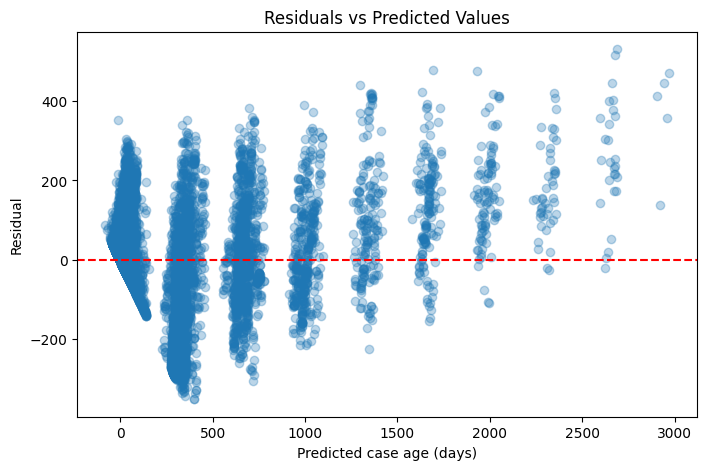

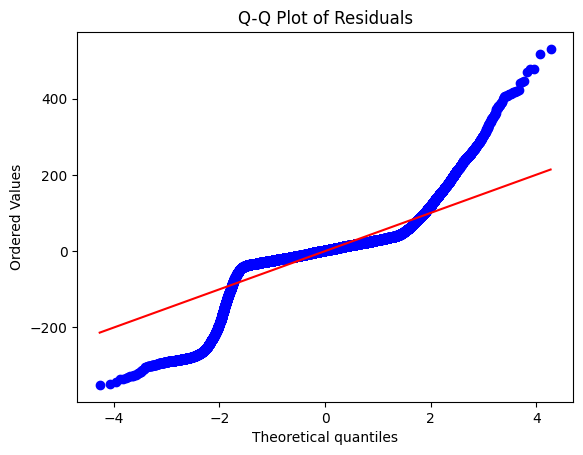

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

# Residuals vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted case age (days)")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

# Q-Q plot for normality of residuals
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

#### Residuals split by request year

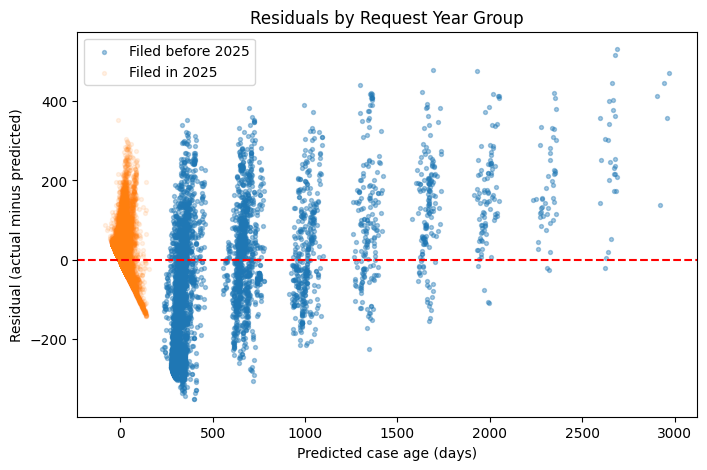

In [ ]:
# mask = True for test cases filed in 2025 (used again in later cells)
mask = (X_test["request_year"] == 2025).to_numpy()
res = (y_test - y_pred).to_numpy()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred[~mask], res[~mask], s=8, alpha=0.4, label="Filed before 2025")
plt.scatter(y_pred[mask], res[mask], s=8, alpha=0.1, label="Filed in 2025")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted case age (days)")
plt.ylabel("Residual (actual minus predicted)")
plt.title("Residuals by Request Year Group")
plt.legend()
plt.show()

#### Why is R^2 so high? Case age by request year

In [ ]:
linear_df.groupby("request_year")["case_age_days"].agg(["count", "median", "mean", "max"]).round(1)


,count,median,mean,max
request_year,,,,
2016,32,3360.5,3328.8,3478
2017,151,2941.0,2931.3,3217
2018,194,2525.0,2523.9,2877
2019,460,2145.0,2144.6,2503
2020,790,1795.5,1792.9,2167
2021,934,1440.5,1432.9,1800
2022,1781,991.0,1017.6,1433
2023,4593,675.0,679.4,1090
2024,17252,148.0,188.3,721


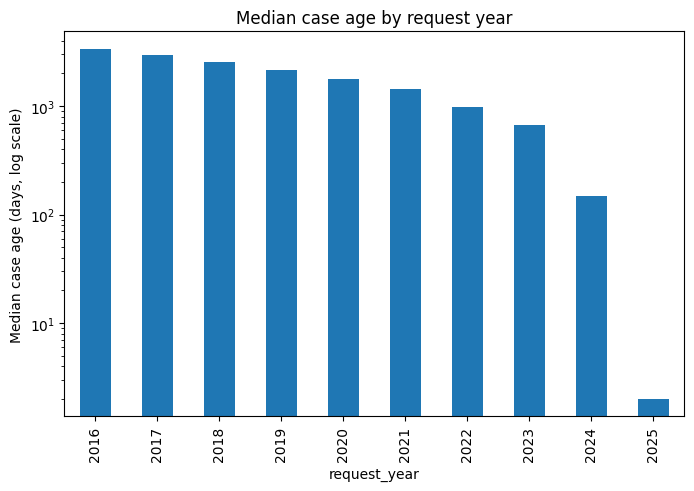

In [ ]:
import matplotlib.pyplot as plt
linear_df.groupby("request_year")["case_age_days"].median().plot(kind="bar", figsize=(8, 5))
plt.yscale("log")
plt.ylabel("Median case age (days, log scale)")
plt.title("Median case age by request year")
plt.show()

#### Baseline refit without request_year

In [ ]:
from sklearn.metrics import mean_absolute_error

X_train_ny = X_train.drop(columns=["request_year"])
X_test_ny = X_test.drop(columns=["request_year"])

preprocessor_ny = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("origin", case_origin_transformer, case_origin_feature),
    ("num", numeric_transformer, [c for c in numeric_features if c != "request_year"])
])
ny_pipeline = Pipeline(steps=[("preprocessor", preprocessor_ny), ("regressor", LinearRegression())])
ny_pipeline.fit(X_train_ny, y_train)
y_pred_ny = ny_pipeline.predict(X_test_ny)

print(f"No request_year RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ny)):.2f}")
print(f"No request_year MAE: {mean_absolute_error(y_test, y_pred_ny):.2f}")
print(f"No request_year R²: {r2_score(y_test, y_pred_ny):.4f}")

No request_year RMSE: 160.30
No request_year MAE: 52.85
No request_year R²: 0.3576


#### Where does the error come from? Long cases

In [ ]:
errors = y_test - y_pred
labels = ["0-7 days", "8-30 days", "31-90 days", "90+ days"]

# Group test cases by their ACTUAL age
bucket = pd.cut(y_test, bins=[-1, 7, 30, 90, np.inf], labels=labels)
sq_dev = (y_test - y_test.mean()) ** 2

tail = pd.DataFrame({
    "pct_of_cases": (bucket.value_counts(normalize=True, sort=False) * 100).round(1),
    "MAE_days": errors.abs().groupby(bucket, observed=False).mean().round(1),
    "pct_of_variance": (sq_dev.groupby(bucket, observed=False).sum() / sq_dev.sum() * 100).round(1),
    "pct_of_squared_error": ((errors ** 2).groupby(bucket, observed=False).sum() / (errors ** 2).sum() * 100).round(1),
})
print(tail)
print("Std of case_age_days:", y_test.std())

               pct_of_cases  MAE_days  pct_of_variance  pct_of_squared_error
case_age_days                                                               
0-7 days               65.9      18.6              3.7                  16.0
8-30 days              16.6      27.0              0.5                  16.0
31-90 days              8.9      56.2              0.1                  19.7
90+ days                8.7     117.5             95.7                  48.2
Std of case_age_days: 199.99803538349767


#### Actual vs predicted by request **year**

In [ ]:
by_year = pd.DataFrame({
    "year": X_test["request_year"].to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": y_pred
}).groupby("year").mean().round(1)
print(by_year)
print("Share of 2025 predictions below 0:", (y_pred[mask] < 0).mean())

      actual  predicted
year                   
2016  3303.4     2938.6
2017  2909.9     2652.9
2018  2491.8     2311.9
2019  2146.8     1982.0
2020  1792.8     1662.5
2021  1433.6     1337.5
2022  1020.3      999.9
2023   685.2      668.1
2024   186.5      320.3
2025    13.2        7.5
Share of 2025 predictions below 0: 0.38727816120285924


In [ ]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
log_pipeline.fit(X_train, y_train_log)

y_pred_log = log_pipeline.predict(X_test)
y_pred_log_backtransformed = np.expm1(y_pred_log)  # back to real days for comparison

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_backtransformed))
r2_log = r2_score(y_test, y_pred_log_backtransformed)

print(f"Log-model RMSE (back-transformed): {rmse_log:.2f}")
print(f"Log-model R²: {r2_log:.4f}")
print("Largest back-tranformed prediction (days):", y_pred_log_backtransformed.max())

Log-model RMSE (back-transformed): 14353.88
Log-model R²: -5150.0248
Largest back-tranformed prediction (days): 1702114.2344193587


#### Ridge Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Add scaling to the numeric pipeline (edit the numeric_transformer from before)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Rebuild the ColumnTransformer with the updated numeric_transformer
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, categorical_features),
    ("origin", case_origin_transformer, case_origin_feature),
    ("num", numeric_transformer, numeric_features)
])

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

param_grid = {"regressor__alpha": [0.1, 1.0, 10.0, 100.0]}

grid_search = GridSearchCV(
    ridge_pipeline, param_grid, cv=5,
    scoring="neg_root_mean_squared_error"
)
grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best alpha: {'regressor__alpha': 10.0}
Best CV RMSE: 58.436190209271594


In [ ]:
best_model = grid_search.best_estimator_
y_pred_ridge = best_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge RMSE: {rmse_ridge:.2f}, R²: {r2_ridge:.4f}")

Ridge RMSE: 58.37, R²: 0.9148


#### Random Forest - capped at 50 trees and depth 10

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=50, # Originally did 100 but reducing to 50 trees
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1))  # Use all available cores
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest R²: {r2_rf:.4f}")

Random Forest RMSE: 113.08
Random Forest MAE: 41.65
Random Forest R²: 0.6803


#### Final comparison tables

In [ ]:
def score(pred):
    return [np.sqrt(mean_squared_error(y_test, pred)),
            mean_absolute_error(y_test, pred),
            r2_score(y_test, pred)]

results = pd.DataFrame(
    [score(y_pred), score(y_pred_ny), score(y_pred_ridge), score(y_pred_rf)],
    columns=["RMSE", "MAE", "R2"],
    index=["Linear (baseline)", "Linear, no request_year", "Ridge", "Random Forest"]
).round(4)
results

,RMSE,MAE,R2
Linear (baseline),58.3758,31.9289,0.9148
"Linear, no request_year",160.2955,52.8462,0.3576
Ridge,58.3747,31.9216,0.9148
Random Forest,113.0790,41.6466,0.6803


#### Real World Applications evidence (Cases filed in 2025 look like new requests)

In [ ]:
results_2025 = pd.DataFrame([score(p, mask) for p in preds],
                            columns=["RMSE", "MAE", "R2"], index=names)

# Benchmark: always guess the average 2025 case age from the training data
naive = np.full(mask.sum(), y_train[X_train["request_year"] == 2025].mean())
results_2025.loc["Always guess 2025 average"] = [
    np.sqrt(mean_squared_error(y_test[mask], naive)),
    mean_absolute_error(y_test[mask], naive),
    r2_score(y_test[mask], naive)]

print("2025 test cases:", mask.sum())
results_2025 = results_2025.round(4)
results_2025

2025 test cases: 64912


,RMSE,MAE,R2
Linear (baseline),32.9831,22.2316,-0.1475
"Linear, no request_year",86.4636,31.8031,-6.8859
Ridge,32.9681,22.2230,-0.1465
Random Forest,40.5333,25.7988,-0.7330
Always guess 2025 average,30.7899,16.8265,-0.0000


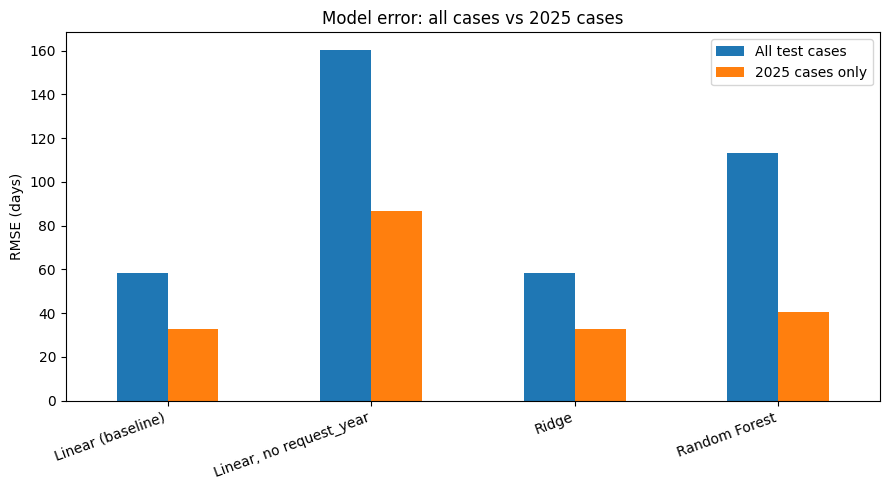

In [ ]:
cmp = pd.DataFrame({"All test cases": results["RMSE"],
                    "2025 cases only": results_2025["RMSE"].iloc[:4]})
cmp.plot(kind="bar", figsize=(9, 5))
plt.ylabel("RMSE (days)")
plt.title("Model error: all cases vs 2025 cases")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Logistic Regression

In [ ]:
X = logistic_df.drop(
    columns=["service_request_id", "closed_within_30_days"]
)

y = logistic_df["closed_within_30_days"]

### K Means Classification